<a href="https://colab.research.google.com/github/SiddhantUke/LangGraph/blob/main/Persistance_10_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **DISCLAIMERS**/ HOW TO DO ANY LANGRAPH WORKFLOW

In [13]:
"""

1) INSTALL PACKAGE


2) SETUP THE LLM



3) State Class — Complete Workflow in Words

A State Class is a structured container that stores all the important information required by the workflow.

The main purpose of the State is to carry information from one step of the workflow to the next step.

======> Create the State Class

First, we define a State Class containing the fields that our workflow needs.

For example, the State can contain:

Topic — The main subject the user is asking about.
Question — The exact question provided by the user.
Context — Relevant information retrieved or generated during the workflow.
Response — The final response generated by the LLM.
Sources — Information about where the retrieved context came from.


4) CREATE A GRAPH AND VISUALIZE THE FUNCTION WHAT WE ACTUALLY NEED!

5) CREATE A FUNCTION OR THE NODES

6)

"""

'\n\n1) INSTALL PACKAGE \n\n\n2) SETUP THE LLM \n\n\n\n3) State Class — Complete Workflow in Words\n\nA State Class is a structured container that stores all the important information required by the workflow.\n\nThe main purpose of the State is to carry information from one step of the workflow to the next step.\n\n======> Create the State Class\n\nFirst, we define a State Class containing the fields that our workflow needs.\n\nFor example, the State can contain:\n\nTopic — The main subject the user is asking about.\nQuestion — The exact question provided by the user.\nContext — Relevant information retrieved or generated during the workflow.\nResponse — The final response generated by the LLM.\nSources — Information about where the retrieved context came from.\n\n\n4) CREATE A GRAPH AND VISUALIZE THE FUNCTION WHAT WE ACTUALLY NEED! \n\n5) CREATE A FUNCTION OR THE NODES \n\n6) \n\n'

In [1]:
!pip install langgraph
!pip install langchain_groq


### Setting Up the Module/Library

In [113]:
from typing import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver

from langchain_groq import ChatGroq

from google import genai
from google.colab import userdata

import os

### Setting Up The LLM 1


In [114]:
import os
from google.colab import userdata

os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")

from groq import Groq

client = Groq()

In [116]:
llm = ChatGroq(
    model = "qwen/qwen3.6-27b",
    temperature=0.7
)





---



### Setting Up The LLM 2

## Configure the SDK with your API key

You create a client using your API key, but instead of pasting your key into the notebook, you'll read it from Colab Secrets thanks to `userdata`.

In [117]:
from google import genai
from google.colab import userdata

GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')
client = genai.Client(api_key=GOOGLE_API_KEY)

#### Calling Different Model at One Place For Checking the Response of Each Model.

In [118]:
MODEL_ID = "gemini-3.5-flash" # @param ["gemini-3.5-flash", "gemini-3.7-flash", "gemini-3.5-flash-lite", "gemini-2.5-pro"] {"allow-input":true, isTemplate: true}







---



### Checking the Content ------> 1

In [119]:
class JokeState(TypedDict):

    topic : str
    joke : str
    explanation : str
    # rating

### Building the FUNCTION/NODE ------> 3


In [137]:
## CREATE A Gen_Joke Function

def Gen_Joke(state: JokeState):

    ## Generate the Joke
    prompt = f"""
            Generate ONE short, funny joke about {state['topic']}.

            Return ONLY the final joke.

            Do not provide:
            - reasoning
            - analysis
            - brainstorming
            - alternatives
            - explanations
            - <think> tags
            """

    response = llm.invoke(prompt).content


    ## Save To The particular content
    return {"joke": response}

In [136]:
## Create A Gen_Exp Function

def Gen_Exp(state: JokeState):

    ## Generate the explain by Gemini
    Exp_prompt = f"""
Explain the following joke clearly and briefly.

Joke:
{state['joke']}

Explain why it is funny and what reference
or character trait it uses.

Do not generate another joke.
"""

    # E_P_response = str(MODEL_ID.invoke(Exp_prompt).content)

    E_P_response = client.models.generate_content(
        model = MODEL_ID,
        contents = Exp_prompt)

    ## Save our Explaination
    return {"explanation": E_P_response.text}

### TESTING THE GEMINI MODEL

In [86]:
# # from google import genai
# # from google.colab import userdata

# # API_KEY = userdata.get("GOOGLE_API_KEY")

# # client = genai.Client(api_key=API_KEY)

# MODEL_ID = "gemini-3.6-flash"

# response = client.models.generate_content(
#     model=MODEL_ID,
#     contents="Explain RAG in simple words"
# )

# print(response)

sdk_http_response=HttpResponse(
  headers=<dict len=11>
) candidates=[Candidate(
  content=Content(
    parts=[
      Part(
        text="""**RAG** stands for **Retrieval-Augmented Generation**. 

In simple words, RAG is a technique that gives an AI an **"open-book exam."**

---

### The Problem RAG Solves
Normally, an AI (like ChatGPT) answers questions based only on what it memorized in the past. This is like taking a **closed-book exam**. 

This causes two big problems:
1. **It can make things up** (called "hallucinating") if it doesn't remember the answer correctly.
2. **It doesn't know your private or recent data** (like your personal notes or your company’s internal documents).

---

### How RAG Fixes This
Instead of forcing the AI to answer from memory, RAG allows the AI to **look up information first** before answering. 

Here is how it works in **3 simple steps**:

1. **Retrieve (Find):** When you ask a question, the system searches through a specific set of documents (like a 

### Building the Graph ------> 2


In [133]:
## Generate a Graph

graph = StateGraph(JokeState)

## Create a Nodes

graph.add_node("Gen_Joke" , Gen_Joke)
graph.add_node("Gen_Exp" ,Gen_Exp)

## Create an Edges

graph.add_edge(START, "Gen_Joke")
graph.add_edge("Gen_Joke", "Gen_Exp")
graph.add_edge("Gen_Exp", END)


## Add Check pointer

CHECKPOINTER = InMemorySaver()


## Compile

Persistance_chatBot = graph.compile(checkpointer = CHECKPOINTER)


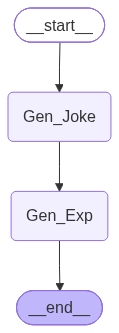

In [134]:
Persistance_chatBot

In [135]:
config3 = {
    "configurable": {
        "thread_id": "3"
    }
}

initial_state = {
    "topic": "Eren Yeager"
}

result = Persistance_chatBot.invoke(
    initial_state,
    config=config3
)

print(result)

{'topic': 'Eren Yeager', 'joke': '\n<think>\nThinking Process:\n\n1.  **Deconstruct the Request:**\n    *   Topic: Eren Yeager (from Attack on Titan).\n    *   Format: ONE short, funny joke.\n    *   Constraints: Return ONLY the final joke. No reasoning, analysis, brainstorming, alternatives, explanations, or tags.\n\n2.  **Brainstorming Angles (Mental Sketching):**\n    *   *Keywords:* Eren, Titan, Freedom, Hardening, Jaw Titan (Armin), Armored Titan (Reiner), Founding Titan, Spoilers (Rumbling), "I\'ll keep walking," Yeagerists.\n    *   *Idea 1:* Eren and relationships? "Eren broke up with his girlfriend because she wasn\'t free enough." (A bit dark/cliché).\n    *   *Idea 2:* Hardening joke? "Why did Eren get a speeding ticket? He hardened his defense." (Weak pun).\n    *   *Idea 3:* Armin inside the Jaw? "Why does Eren always win arm wrestles? Because he has Armin in his jaw." (Too lore-specific, maybe not "funny" enough).\n    *   *Idea 4:* The name "Yeager". Sounds like "Eager".

In [138]:

print(result['explanation'])

This joke is a pun based on pronunciation:

The last name of the character, Eren **Yeager**, sounds exactly like the English word **"eager"** (which means highly enthusiastic, impatient, or keen). 

The joke is also fitting because, in the anime *Attack on Titan*, Eren is famously known for his intense, angry, and impatient personality.


In [139]:
list(Persistance_chatBot.get_state_history(config3))

[StateSnapshot(values={'topic': 'Eren Yeager', 'joke': '\n<think>\nThinking Process:\n\n1.  **Deconstruct the Request:**\n    *   Topic: Eren Yeager (from Attack on Titan).\n    *   Format: ONE short, funny joke.\n    *   Constraints: Return ONLY the final joke. No reasoning, analysis, brainstorming, alternatives, explanations, or tags.\n\n2.  **Brainstorming Angles (Mental Sketching):**\n    *   *Keywords:* Eren, Titan, Freedom, Hardening, Jaw Titan (Armin), Armored Titan (Reiner), Founding Titan, Spoilers (Rumbling), "I\'ll keep walking," Yeagerists.\n    *   *Idea 1:* Eren and relationships? "Eren broke up with his girlfriend because she wasn\'t free enough." (A bit dark/cliché).\n    *   *Idea 2:* Hardening joke? "Why did Eren get a speeding ticket? He hardened his defense." (Weak pun).\n    *   *Idea 3:* Armin inside the Jaw? "Why does Eren always win arm wrestles? Because he has Armin in his jaw." (Too lore-specific, maybe not "funny" enough).\n    *   *Idea 4:* The name "Yeager"

In [140]:
## PArticular jagah pe jaao ! Topic ki Value aai hui hai !
## Hr checkpoint pe checkpoint id hota hai !

Persistance_chatBot.get_state({"configurable":{"thread_id":"3", 'checkpoint_id': '1f1a05d1-a6dd-6b47-8001-be72d00fe7ab'}})


StateSnapshot(values={'topic': 'Eren Yeager', 'joke': '\n<think>\nThinking Process:\n\n1.  **Deconstruct the Request:**\n    *   Topic: Eren Yeager (from Attack on Titan).\n    *   Format: ONE short, funny joke.\n    *   Constraints: Return ONLY the final joke. No reasoning, analysis, brainstorming, alternatives, explanations, or tags.\n\n2.  **Brainstorming Angles (Mental Sketching):**\n    *   *Keywords:* Eren, Titan, Freedom, Hardening, Jaw Titan (Armin), Armored Titan (Reiner), Founding Titan, Spoilers (Rumbling), "I\'ll keep walking," Yeagerists.\n    *   *Idea 1:* Eren and relationships? "Eren broke up with his girlfriend because she wasn\'t free enough." (A bit dark/cliché).\n    *   *Idea 2:* Hardening joke? "Why did Eren get a speeding ticket? He hardened his defense." (Weak pun).\n    *   *Idea 3:* Armin inside the Jaw? "Why does Eren always win arm wrestles? Because he has Armin in his jaw." (Too lore-specific, maybe not "funny" enough).\n    *   *Idea 4:* The name "Yeager".

In [ ]:
{'topic': 'Goku', 'joke': '\n<think>\nThinking Process:\n\n1.  **Deconstruct the topic:** Goku (Dragon Ball).\n    *   Key traits: Loves food, loves fighting, naive, forgetful, hair changes color/shape when powering up (Super Saiyan), screams a lot, has a brother (Vegeta is his rival/friend), has a son (Gohan) who is smarter, eats until he passes out, trains constantly, destroys planets by accident, "Kamehameha", "Kaio-ken".\n\n2.  **Brainstorm angles for humor:**\n    *   *Angle 1: Food.* Goku always eats everything.\n        *   *Idea:* Goku goes to a restaurant. How much does he eat? He eats the restaurant.\n        *   *Drafting:* Why did Goku get kicked out of the buffet? He ate the buffet. (Too simple).\n        *   *Refinement:* Why doesn\'t Goku have a credit card? Because he always maxes out his appetite. (A bit weak).\n        *   *Better approach:* Play on the "all you can eat" concept.\n        *   *Joke:* Why did Goku break up with his girlfriend? She wanted a quiet dinner, and he wanted an "all-you-can-eat" fight. (Meh).\n        *   *Classic structure:* Why did Goku cross the road? To get to the other side... of the buffet. (No).\n        *   *Winner idea:* Focus on the bill. Goku eats so much the bill is astronomical. Or he powers up to pay? No.\n        *   *Best Food Joke:* Why does Goku make a terrible roommate? Because he always "powers up" the grocery bill! Or "He eats until he passes out... literally."\n\n    *   *Angle 2: Hair/Transformation.*\n        *   *Idea:* His hair changes. Bad hair days?\n        *   *Joke:* Goku never needs a hair stylist. He just screams until his hair stands up.\n        *   *Refinement:* Why did Goku get a haircut? He wanted to go from Super Saiyan to "Super Sane". (A bit dad-joke style, but good).\n        *   *Another:* What\'s Goku\'s favorite hairstyle? A "Saiyan" cut. (Pun on "Saiyan" and "Slaying"? No. "Saiyan" sounds like "Saying"? No. "Saiyan" sounds like "Slaying"? No. "Saiyan" -> "Saiyan" -> "Saying"? No. How about "Saiyan" -> "Slayin\'"? No.\n        *   *Better Pun:* Why is Goku bad at hiding? Because he always has a "hair-raising" appearance. (Okay).\n        *   *Transformation joke:* Why does Goku\'s hair defies gravity? Because he\'s always on top of the world. (Weak).\n        *   *Winner idea:* The screaming. "Why does Goku scream before he fights? Because he\'s trying to get his hair to stand up without hairspray."\n\n    *   *Angle 3: Naivety/Intelligence.*\n        *   *Idea:* Goku is dumb.\n        *   *Joke:* Why did Goku fail math? Because he couldn\'t find the "Kamehameha" solution. (No).\n        *   *Refinement:* Goku thinks "Kamehameha" is a restaurant. (Common trope).\n        *   *Joke:* Why did Goku bring a calculator to the fight? To calculate the "Kaio-ken" multiplier. (Nerd joke).\n        *   *Winner idea:* Focus on his brother Vegeta. Vegeta tries to be smart, Goku isn\'t.\n        *   *Joke:* Why does Vegeta hate grocery shopping with Goku? Because Goku always asks, "Is there enough for everyone?" and Vegeta screams, "I am the prince of all Saiyans, I eat first!" (Too long).\n        *   *Better:* Why did Goku get lost on his way to the tournament? He was too busy looking for the "Way of the Warrior" restaurant.\n\n    *   *Angle 4: Kamehameha/Puns.*\n        *   *Idea:* Puns on Kamehameha.\n        *   *Kamehameha* -> *Came home a*?\n        *   *Joke:* Why did Goku\'s attack miss? He came home a little too late. (Kamehameha -> Came home a).\n        *   *Refinement:* Why didn\'t Goku\'s blast hit Frieza? Because it *Kamehameha* (Came home a) different time. (A bit of a stretch).\n        *   *Better Pun:* "Kamehameha" -> "Came home a".\n        *   *Joke:* Why did Goku\'s special move fail? Because he *Kamehameha* (Came home a) loser. (Mean? No).\n        *   *Joke:* Why is Goku good at returning packages? Because he always *Kamehameha*. (This is a classic pun structure. "Kamehameha" sounds like "Came home a...").\n        *   *Result:* Why is Goku the best delivery driver? Because he always *Kamehameha* (Came home a) winner? No.\n        *   *Result:* Why did Goku get promoted? Because he always *Kamehameha*. (Implies he comes home a lot? No, the pun relies on "Came home a").\n        *   *Best Pun:* Why is Goku so good at returning gifts? Because he always *Kamehameha* (Came home a gift? No).\n        *   *Let\'s try "Kaio-ken".* "Kaio-ken" -> "Kai-o-ken"? No.\n        *   *Let\'s try "Saiyan".* "Saiyan" -> "Saying".\n        *   *Joke:* What did Goku say when he saw the buffet? "Saiyan" (Saying) "I\'m hungry!" (Too simple).\n\n    *   *Angle 5: Gohan.*\n        *   *Idea:* Gohan is the smart one. Goku leaves the smart work to Gohan.\n        *   *Joke:* Why does Goku let Gohan do the taxes? Because Goku thinks "Kamehameha" is a tax bracket. (Funny to fans).\n        *   *Refinement:* Why did Goku call Gohan during the fight? He needed help with the math, and Vegeta was busy screaming.\n\n3.  **Select the best option(s):**\n    *   *Option A1 (Food + Power Level):* Why does Goku make a terrible bank robber? Because whenever he tries to count the money, he gets distracted by the snacks and powers up looking for more! (A bit wordy).\n    *   *Option 2 (Hair + Screaming):* Why does Goku never need hair gel? Because he can just scream until his hair stands up! (Solid, relatable to the anime trope).\n    *   *Option 3 (Pun):* Why is Goku bad at secret missions? Because he always lets his hair down... and then powers it back up. (Okay).\n    *   *Option 4 (The "Kamehameha" Pun):* This is usually the crowd-pleaser for text jokes.\n        *   *Setup:* Why did Goku\'s attack miss the target?\n        *   *Punchline:* Because it *Kamehameha* (Came home a) miss! Or "Because he *Kamehameha* (Came home a) different time."\n        *   *Actually, the best "Kamehameha" pun is:* Why is Goku so good at returning packages? Because he always *Kamehameha*. (Wait, "Kamehameha" sounds like "Came home a". So "He always came home a..." doesn\'t make sense as a pun for returning packages. The pun works if the phrase is "Came home". So: Why did Goku\'s blast return to him? Because it *Kamehameha*. Yes! That works. "Kamehameha" = "Came home".)\n        *   *Joke:* Why did Goku\'s Kamehameha hit him in the face? Because it *Kamehameha*! (This is a strong pun).\n\n    *   *Option 5 (Vegeta dynamic):*\n        *   *Joke:* Why did Vegeta break up with Goku? Because their relationship had no "power level" and Goku kept asking for snacks instead of talking. (A bit weak).\n        *   *Better:* What\'s the difference between Goku and Vegeta? Vegeta has a plan; Goku has a plan to eat. (Observational humor).\n\n4.  **Final Polish (Choosing a balanced joke):**\n    *   I want a joke that hits multiple notes if possible, or just one really solid one.\n    *   *The "Kamehameha" pun is clever but might be too punny for some.*\n    *   *The Food joke is universally understood.*\n    *   *Combination:* Why did Goku get kicked out of the library? He was screaming "KAMEHAMEHA!" every time he tried', 'explanation': 'It looks like you didn\'t include the joke! \n\nHowever, here is a classic **Goku/Dragon Ball Z joke** along with a clear and brief explanation:\n\n***\n\n**The Joke:**\n> **How many Super Saiyans does it take to change a lightbulb?**\n> *Just one, but it takes three episodes, and Krillin dies in the process.*\n\n***\n\n### **The Explanation:**\nThis joke pokes fun at two of the most famous tropes in the *Dragon Ball Z* anime:\n1. **The slow pacing:** Characters in the show spend an notoriously long time "powering up" (transforming into Super Saiyans), with single actions often dragging out across multiple television episodes.\n2. **Krillin\'s frequent deaths:** Goku’s best friend, Krillin, is famous for dying repeatedly throughout the series, often serving as the emotional trigger that forces Goku to power up and save the day.'}
